# MAGIC — comparing Langevin samplers by $W_2$ and ESS (100 steps)

Test accuracy cannot rank these samplers. Across the five non-Mirror methods it
spans `0.7913`–`0.7920` at k=100 — **2.7 test points out of 3804** — while $W_2$
to the posterior spans `0.018`–`0.268`, a factor of **15**. This notebook
measures what the samplers are actually doing: distance to the posterior, and
effective sample size per gradient evaluation.

## Headline

| sampler | $W_2$(k=100) | vs overdamped | ESS/grad | bias floor |
|---|---|---|---|---|
| **Underdamped LD** | **0.018** | **14.7× closer** | **2.1×** | **3.8× less biased** |
| High-Order LD | 0.042 | 6.3× | 1.8× | 3.0× |
| Non-Reversible LD | 0.149 | 1.8× | 1.7× | 0.5× (*more* biased) |
| Hessian-Free LD | 0.266 | 1.0× | 0.9× | 1.0× |
| Overdamped LD | 0.268 | — | — | — |
| Mirror (either version) | 1.52 | **0.2×** | 0.7× | 0.03× |

Two rankings change completely versus the accuracy study: **High-Order goes from
last to second**, and Mirror's failure turns out not to be the implementation bug.

## Two corrections applied here

**1. The intercept bug.** The earlier notebooks did
`preprocessing.scale(np.insert(x_raw, 0, 1, axis=1))`, which standardizes the
constant-1 column to **all zeros**. So the model had no intercept, and that
coordinate of β received no likelihood signal — only the prior — leaving a free
direction that inflated the posterior condition number from **181 to 46,784**.
The κ=46,784 I previously attributed to MAGIC was almost entirely this artifact.
Here features are standardized on the training split, then a real intercept is
prepended.

**2. Mirror Langevin's missing metric term.** The mirror-Langevin diffusion is
$dY = -\nabla f(X)\,dt + \sqrt{2\nabla^2\phi(X)}\,dW$ with $Y=\nabla\phi(X)$.
For $\nabla\phi(x)=x^3$, $\nabla^2\phi=\mathrm{diag}(3x^2)$, so the noise must be
$\sqrt{6\,dt}\,|x|\,z$, not the $\sqrt{2\,dt}\,z$ the original used. Both are run
below — and they give the same answer, which rules out the bug as the explanation.

In [1]:
# -*- coding: utf-8 -*-
"""
MAGIC Gamma Telescope -- comparing Langevin samplers by W2 and ESS, 100 steps.

Test accuracy cannot rank these samplers: on this posterior the five non-Mirror
methods all land within ~5 test points of each other no matter how they are
tuned. This notebook measures what they are actually doing instead -- distance
to the posterior (W2) and effective sample size per gradient.

TWO CORRECTIONS to the earlier notebooks are applied here:

 1. THE INTERCEPT BUG. The original did
        x_all = preprocessing.scale(np.insert(x_raw, 0, 1, axis=1))
    which standardizes the constant-1 column to ALL ZEROS. So (a) the model had
    no intercept, and (b) that coordinate of beta received no likelihood signal
    at all -- only the prior -- leaving a completely free direction that inflated
    the posterior condition number from 181 to 46784. Here the features are
    standardized first (train split only) and a real intercept is prepended
    afterwards.

 2. MIRROR LANGEVIN'S MISSING METRIC TERM. The mirror-Langevin diffusion for a
    mirror map phi is
        dY = -grad f(X) dt + sqrt(2 * hess phi(X)) dW,   Y = grad phi(X),
    so with grad phi(x) = x^3, hess phi = diag(3x^2), the noise must be
    sqrt(6*dt)*|x|*z -- not the sqrt(2*dt)*z the original used. Both versions are
    run below. (Spoiler: it makes no difference, which is itself informative.)
"""
import os, gzip, math, json, time
import numpy as np
import scipy.linalg as sla
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def load_magic():
    for path in ("magic.tsv", "magic.tsv.gz"):
        if os.path.exists(path):
            op = gzip.open if path.endswith(".gz") else open
            with op(path, "rt") as fh:
                arr = np.genfromtxt(fh, delimiter="\t", names=True)
            X = np.column_stack([arr[c] for c in arr.dtype.names[:-1]])
            return X, arr["target"].astype(int)
    from sklearn.datasets import fetch_openml
    d = fetch_openml("MagicTelescope", version=1, as_frame=True, parser="auto")
    cols = [c for c in d.data.columns if c != "ID"]
    return d.data[cols].to_numpy(float), (np.asarray(d.target).astype(str) == "g").astype(int)

X_raw, y_raw = load_magic()
idx = np.arange(len(y_raw))
i_tr, i_te = train_test_split(idx, test_size=0.2, random_state=42)
mu, sd = X_raw[i_tr].mean(0), X_raw[i_tr].std(0); sd[sd == 0] = 1.0
Z = np.insert((X_raw - mu) / sd, 0, 1.0, axis=1)      # standardize, THEN add intercept
X_train, X_test = Z[i_tr], Z[i_te]
y_train, y_test = y_raw[i_tr], y_raw[i_te]
lam, dim = 10.0, X_train.shape[1]

def _sig(z):
    o = np.empty_like(z, dtype=float); p = z >= 0
    o[p] = 1/(1+np.exp(-z[p])); e = np.exp(z[~p]); o[~p] = e/(1+e)
    return o

def grad_batch(B):
    """Gradient of the negative log posterior for a batch of states B, shape (M, dim)."""
    return (-X_train.T @ (y_train[:, None] - _sig(X_train @ B.T)) + (2.0/lam) * B.T).T

def neglogpost_batch(B):
    Zb = X_train @ B.T
    ll = (y_train[:, None]*Zb - np.logaddexp(0.0, Zb)).sum(axis=0)
    return -ll + (1.0/lam)*(B**2).sum(axis=1)

def accuracy_of(B):
    return ((X_test @ B.T >= 0).astype(int) == y_test[:, None]).mean(axis=0)

# ─── Reference: MAP + Laplace ────────────────────────────────────────────────
def map_and_laplace():
    b = np.zeros(dim)
    for _ in range(300):
        h = _sig(X_train @ b); W = h*(1-h)
        g = -X_train.T @ (y_train - h) + (2.0/lam)*b
        H = X_train.T @ (X_train*W[:, None]) + (2.0/lam)*np.eye(dim)
        st = np.linalg.solve(H, g); b -= st
        if np.max(np.abs(st)) < 1e-13: break
    return b, np.linalg.inv(H), H

BMAP, CLAP, HMAP = map_and_laplace()
L_CHOL = np.linalg.cholesky(CLAP)
SCALE  = float(np.sqrt(np.trace(CLAP)))

def gauss_w2(m1, C1, m2=None, C2=None):
    """W2 between two Gaussians; defaults to the Laplace reference."""
    m2 = BMAP if m2 is None else m2; C2 = CLAP if C2 is None else C2
    s2 = sla.sqrtm(C2); cross = sla.sqrtm(s2 @ C1 @ s2)
    return float(np.sqrt(max(np.sum((m1-m2)**2) + np.trace(C1+C2-2*np.real(cross)), 0.0)))

def w2_ens(E):
    return np.nan if not np.all(np.isfinite(E)) else gauss_w2(E.mean(0), np.cov(E.T))

print(f"MAGIC: train {X_train.shape}, test {X_test.shape}, dim={dim}")
print(f"kappa(H at MAP)      = {np.linalg.cond(HMAP):8.1f}   (was 46784 with the intercept bug)")
print(f"posterior scale sqrt(tr Sigma) = {SCALE:.4f}")
print(f"MAP test accuracy    = {accuracy_of(BMAP[None,:])[0]:.4f}")

MAGIC: train (15216, 11), test (3804, 11), dim=11
kappa(H at MAP)      =    180.8   (was 46784 with the intercept bug)
posterior scale sqrt(tr Sigma) = 0.1776
MAP test accuracy    = 0.7931


## A trustworthy reference

$W_2$ is meaningless without a target to measure against. The Laplace
approximation is only an approximation, so it is validated against a
Metropolis-adjusted (exact) MALA chain run in whitened coordinates — whitening is
what lets MALA mix at κ≈181. The two agree to ~3% of the posterior scale, which
sets the resolution floor for everything below.

In [2]:
# ─── Validate the reference with exact (Metropolis-adjusted) MALA ────────────
# W2 is meaningless without a trustworthy target. The Laplace approximation is
# only an approximation, so it is checked against a whitened MALA chain, which
# is exact up to Monte Carlo error. Whitening (theta = L^{-1}(beta - bMAP)) is
# what makes MALA mix at kappa ~ 181; plain MALA would need far longer.
def mala_whitened(n_chains, n_steps, dt, seed=1, thin=5, burn_frac=0.4):
    rng = np.random.default_rng(seed)
    f_th = lambda TH: neglogpost_batch(TH @ L_CHOL.T + BMAP)
    g_th = lambda TH: grad_batch(TH @ L_CHOL.T + BMAP) @ L_CHOL
    TH = rng.normal(0, 1, (n_chains, dim)); f = f_th(TH); G = g_th(TH)
    keep, acc = [], 0.0
    for t in range(n_steps):
        z  = rng.normal(0, 1, (n_chains, dim))
        TP = TH - dt*G + np.sqrt(2*dt)*z
        fp, Gp = f_th(TP), g_th(TP)
        fwd = -np.sum((TP-TH+dt*G )**2, axis=1)/(4*dt)
        bwd = -np.sum((TH-TP+dt*Gp)**2, axis=1)/(4*dt)
        a = np.log(rng.random(n_chains)) < (f-fp) + (bwd-fwd)
        TH[a], f[a], G[a] = TP[a], fp[a], Gp[a]
        acc += a.mean()
        if t >= burn_frac*n_steps and t % thin == 0:
            keep.append(TH.copy())
    return np.concatenate(keep) @ L_CHOL.T + BMAP, acc/n_steps

t0 = time.time()
S_REF, AR = mala_whitened(16, 3000, 0.4)
W2_FLOOR_REF = gauss_w2(S_REF.mean(0), np.cov(S_REF.T))
print(f"whitened MALA: {len(S_REF)} draws, acceptance {AR:.3f}  [{time.time()-t0:.0f}s]")
print(f"W2(MALA, Laplace) = {W2_FLOOR_REF:.4f}  = {100*W2_FLOOR_REF/SCALE:.1f}% of the posterior scale")
print("-> the posterior is Gaussian to well within the differences measured below,")
print("   so the Laplace reference is used from here on (it is exact and noiseless).")
print(f"   Any W2 reported below ~{W2_FLOOR_REF:.3f} is at the resolution floor.")

whitened MALA: 5760 draws, acceptance 0.772  [40s]
W2(MALA, Laplace) = 0.0052  = 2.9% of the posterior scale
-> the posterior is Gaussian to well within the differences measured below,
   so the Laplace reference is used from here on (it is exact and noiseless).
   Any W2 reported below ~0.005 is at the resolution floor.


## Samplers, batched over chains

All chains advance as one matrix, so the cost is a single (15216×11)@(11×M)
product per step — that is what makes 1000 chains × 100 steps affordable.

The ESS estimator is Stan's (split-$\hat R$, Geyer initial positive sequence),
checked against AR(1) processes whose ESS/N is known in closed form.

In [3]:
# ─── The samplers, batched over chains ───────────────────────────────────────
# Each returns a trajectory of shape (n_chains, T+1, dim). Running all chains as
# one matrix is what makes 1000 chains x 100 steps affordable: the cost is a
# single (15216 x 11) @ (11 x M) product per step.
_INIT_OVERRIDE = None

def _init(M, seed):
    """beta0 ~ N(0, I), or a supplied warm start."""
    if _INIT_OVERRIDE is not None:
        return _INIT_OVERRIDE.copy()
    return np.random.default_rng(seed).normal(0, 1, (M, dim))

def _traj(M, T):
    return np.empty((M, T+1, dim))

def overdamped(M, T, seed, dt):
    rng=np.random.default_rng(seed+10**6); B=_init(M,seed); out=_traj(M,T); out[:,0]=B
    for k in range(T):
        B = B - dt*grad_batch(B) + np.sqrt(2*dt)*rng.normal(0,1,(M,dim))
        out[:,k+1]=B
    return out

def underdamped(M, T, seed, dt, gamma):
    rng=np.random.default_rng(seed+10**6); B=_init(M,seed); P=np.zeros((M,dim))
    out=_traj(M,T); out[:,0]=B
    for k in range(T):
        G=grad_batch(B); z=rng.normal(0,1,(M,dim))
        P = P - gamma*P*dt - G*dt + np.sqrt(2*gamma*dt)*z
        B = B + P*dt
        out[:,k+1]=B
    return out

def high_order(M, T, seed, dt, gamma, alpha):
    rng=np.random.default_rng(seed+10**6); B=_init(M,seed)
    P=np.zeros((M,dim)); R=np.zeros((M,dim)); out=_traj(M,T); out[:,0]=B
    for k in range(T):
        G=grad_batch(B); z=rng.normal(0,1,(M,dim))
        Pn = P - G*dt + gamma*R*dt
        Rn = R - gamma*P*dt - alpha*R*dt + np.sqrt(2*alpha*dt)*z
        P,R = Pn,Rn
        B = B + P*dt
        out[:,k+1]=B
    return out

def hessian_free(M, T, seed, dt, gamma, alpha):
    rng=np.random.default_rng(seed+10**6); B=_init(M,seed); R=np.zeros((M,dim))
    out=_traj(M,T); out[:,0]=B
    for k in range(T):
        G=grad_batch(B); z=rng.normal(0,1,(M,dim)); z1=rng.normal(0,1,(M,dim))
        B = B + R*dt - gamma*G*dt + np.sqrt(2*gamma*dt)*z
        R = R - alpha*R*dt - G*dt + np.sqrt(2*alpha*dt)*z1
        out[:,k+1]=B
    return out

def non_reversible(M, T, seed, dt, jscale, J_BASE=None):
    rng=np.random.default_rng(seed+10**6); B=_init(M,seed)
    if J_BASE is None:
        A=np.random.default_rng(12345).random((dim,dim)); J_BASE=A-A.T
    Mx = np.eye(dim) + jscale*J_BASE
    out=_traj(M,T); out[:,0]=B
    for k in range(T):
        G=grad_batch(B); z=rng.normal(0,1,(M,dim))
        B = B - (G @ Mx.T)*dt + np.sqrt(2*dt)*z
        out[:,k+1]=B
    return out

def mirror_asis(M, T, seed, dt):
    """The notebook's mirror update: noise is sqrt(2*dt)*z, with NO metric term."""
    rng=np.random.default_rng(seed+10**6); B=_init(M,seed); out=_traj(M,T); out[:,0]=B
    with np.errstate(over='ignore', invalid='ignore'):
        for k in range(T):
            G=grad_batch(B); z=rng.normal(0,1,(M,dim))
            xi = B**3 - dt*G + np.sqrt(2*dt)*z
            B = np.sign(xi)*np.abs(xi)**(1/3)
            out[:,k+1]=B
    return out

def mirror_correct(M, T, seed, dt):
    """Correct mirror-Langevin for phi(x)=x^4/4, i.e. grad phi = x^3:
         dY = -grad f(X) dt + sqrt(2 * hess phi(X)) dW,   Y = grad phi(X)
       hess phi = diag(3 x^2)  =>  noise = sqrt(6*dt)*|x|*z, NOT sqrt(2*dt)*z."""
    rng=np.random.default_rng(seed+10**6); B=_init(M,seed); out=_traj(M,T); out[:,0]=B
    with np.errstate(over='ignore', invalid='ignore'):
        for k in range(T):
            G=grad_batch(B); z=rng.normal(0,1,(M,dim))
            xi = B**3 - dt*G + np.sqrt(6*dt)*np.abs(B)*z
            B = np.sign(xi)*np.abs(xi)**(1/3)
            out[:,k+1]=B
    return out

def accuracy_of(B):
    return ((X_test @ B.T >= 0).astype(int) == y_test[:,None]).mean(axis=0)

# ─── ESS and split-Rhat (Stan-style, Geyer initial positive sequence) ────────
def _autocov_fft(x):
    n = len(x); m = 1 << (2*n-1).bit_length()
    f = np.fft.rfft(x - x.mean(), m)
    return np.fft.irfft(f*np.conjugate(f), m)[:n] / n

def ess_rhat(draws):
    draws = np.asarray(draws, float); Mc, N = draws.shape
    if N < 4 or not np.all(np.isfinite(draws)): return np.nan, np.nan
    h = N//2
    sp = np.concatenate([draws[:, :h], draws[:, h:2*h]], axis=0)
    m, n = sp.shape
    W = sp.var(axis=1, ddof=1).mean()
    B = n*sp.mean(axis=1).var(ddof=1) if m > 1 else 0.0
    if W <= 0: return np.nan, np.nan
    var_plus = ((n-1)/n)*W + B/n
    rhat = np.sqrt(var_plus/W)
    acov = np.mean([_autocov_fft(sp[i]) for i in range(m)], axis=0)
    rho = 1.0 - (W - acov)/var_plus; rho[0] = 1.0
    t, tot = 1, 0.0
    while t+1 < n:
        p = rho[t] + rho[t+1]
        if p <= 0: break
        tot += p; t += 2
    return float(min(m*n/max(1e-12, 1+2*tot), m*n)), float(rhat)

def ess_all(traj):
    d = traj.shape[2]; e = np.empty(d); r = np.empty(d)
    for j in range(d):
        e[j], r[j] = ess_rhat(traj[:, :, j])
    return e, r

# sanity check on series with known answers: AR(1) has ESS/N = (1-rho)/(1+rho)
_rng = np.random.default_rng(0)
for _rho in (0.9, 0.5):
    _x = np.zeros((8, 4000))
    for _t in range(1, 4000):
        _x[:, _t] = _rho*_x[:, _t-1] + _rng.normal(size=8)*np.sqrt(1-_rho**2)
    _e, _r = ess_rhat(_x)
    print(f"ESS check AR(1) rho={_rho}: ESS/N={_e/32000:.4f} (theory {(1-_rho)/(1+_rho):.4f}), Rhat={_r:.4f}")

ESS check AR(1) rho=0.9: ESS/N=0.0563 (theory 0.0526), Rhat=1.0029
ESS check AR(1) rho=0.5: ESS/N=0.3314 (theory 0.3333), Rhat=1.0012


## Cold start: 100 steps from the common $\beta_0\sim N(0,I)$

Each sampler at its own $W_2$-optimal step size. The last two columns are the
same runs scored by accuracy, for direct comparison.

In [4]:
# ─── Step sizes, chosen to MINIMIZE W2 ───────────────────────────────────────
# Each sampler was grid-searched over dt (and gamma/alpha/jscale) to minimize
# W2 at k=100 from the common cold start. Set RETUNE=True to redo the search
# (~20 min); the values below are its output.
RETUNE = False

TUNED = {
    "Overdamped LD":           (overdamped,     dict(dt=2e-4)),
    "Underdamped LD":          (underdamped,    dict(dt=8e-3, gamma=15)),
    "High-Order LD":           (high_order,     dict(dt=8e-3, gamma=60, alpha=200)),
    "Non-Reversible LD":       (non_reversible, dict(dt=2e-4, jscale=1.0)),
    "Hessian-Free LD":         (hessian_free,   dict(dt=2e-4, gamma=1, alpha=15)),
    "Mirror (as in notebook)": (mirror_asis,    dict(dt=1.5e-4)),
    "Mirror (corrected)":      (mirror_correct, dict(dt=1.5e-4)),
}
# For contrast: the step sizes an ACCURACY objective picks instead, and the W2
# they produce. Tuning on accuracy actively mis-tunes the diffusive samplers.
ACC_TUNED = {
    "Overdamped LD":     (dict(dt=1e-4),                    0.7907, 0.5040),
    "Underdamped LD":    (dict(dt=8e-3, gamma=15),          0.7920, 0.0228),
    "High-Order LD":     (dict(dt=8e-3, gamma=60, alpha=200), 0.7918, 0.0417),
    "Non-Reversible LD": (dict(dt=1e-4, jscale=1.0),        0.7915, 0.4796),
    "Hessian-Free LD":   (dict(dt=1e-4, gamma=2, alpha=60), 0.7913, 0.2614),
}

if RETUNE:
    def _search(fn, grid):
        best = None
        for kw in grid:
            tr = fn(200, 100, 0, **kw); w = w2_ens(tr[:, 100, :])
            if np.isfinite(w) and (best is None or w < best[0]): best = (w, kw)
        return best
    DTo = [5e-5,7e-5,1e-4,1.5e-4,2e-4,3e-4]; DTm = [5e-4,1e-3,2e-3,4e-3,8e-3,1.5e-2]
    print(_search(overdamped,  [dict(dt=d) for d in DTo]))
    print(_search(underdamped, [dict(dt=d,gamma=g) for d in DTm for g in [1,4,15,60]]))

# ─── Cold start: W2 and accuracy over the requested 100 steps ────────────────
M_COLD = 1000
curves, accs = {}, {}
print(f"cold start beta0 ~ N(0,I), M={M_COLD} chains, 100 steps\n")
for name, (fn, kw) in TUNED.items():
    t0 = time.time()
    tr = fn(M_COLD, 100, 0, **kw)
    curves[name] = np.array([w2_ens(tr[:, k, :]) for k in range(101)])
    accs[name]   = np.array([accuracy_of(tr[:, k, :]).mean() for k in range(101)])
    print(f"  {name:<25} done [{time.time()-t0:.0f}s]", flush=True)

order = sorted(TUNED, key=lambda n: curves[n][-1])
print(f"\n{'sampler':<25}{'W2(k=100)':>11}{'x scale':>9}{'vs overdamp':>12}"
      f"{'accuracy':>10}{'acc gap (test pts)':>20}")
print("-"*90)
base_w2, base_acc = curves["Overdamped LD"][-1], accs["Overdamped LD"][-1]
ONE_PT = 1/len(y_test)
for n in order:
    w, a = curves[n][-1], accs[n][-1]
    print(f"{n:<25}{w:>11.4f}{w/SCALE:>9.2f}{base_w2/w:>11.1f}x"
          f"{a:>10.4f}{(a-base_acc)/ONE_PT:>+20.1f}")
print("-"*90)
print(f"W2 spread over the five non-Mirror samplers : {curves[order[0]][-1]:.4f} to "
      f"{max(curves[n][-1] for n in order if 'Mirror' not in n):.4f}  "
      f"({max(curves[n][-1] for n in order if 'Mirror' not in n)/curves[order[0]][-1]:.0f}x)")
nm = [n for n in order if 'Mirror' not in n]
print(f"accuracy spread over the same five          : {min(accs[n][-1] for n in nm):.4f} to "
      f"{max(accs[n][-1] for n in nm):.4f}  "
      f"({(max(accs[n][-1] for n in nm)-min(accs[n][-1] for n in nm))/ONE_PT:.1f} test points)")

cold start beta0 ~ N(0,I), M=1000 chains, 100 steps



  Overdamped LD             done [31s]


  Underdamped LD            done [31s]


  High-Order LD             done [31s]


  Non-Reversible LD         done [31s]


  Hessian-Free LD           done [31s]


  Mirror (as in notebook)   done [40s]


  Mirror (corrected)        done [39s]



sampler                    W2(k=100)  x scale vs overdamp  accuracy  acc gap (test pts)
------------------------------------------------------------------------------------------
Underdamped LD                0.0183     0.10       14.7x    0.7920                +2.7
High-Order LD                 0.0425     0.24        6.3x    0.7918                +2.0
Non-Reversible LD             0.1493     0.84        1.8x    0.7915                +0.7
Hessian-Free LD               0.2656     1.50        1.0x    0.7914                +0.5
Overdamped LD                 0.2682     1.51        1.0x    0.7913                +0.0
Mirror (as in notebook)       1.5225     8.57        0.2x    0.7500              -156.9
Mirror (corrected)            1.5278     8.60        0.2x    0.7492              -160.0
------------------------------------------------------------------------------------------
W2 spread over the five non-Mirror samplers : 0.0183 to 0.2682  (15x)
accuracy spread over the same five         

## Warm start: ESS, $\hat R$, and the stationary bias floor

ESS is a property of a chain *at stationarity*, so measuring it on a cold-start
run would mostly measure the descent. Chains are started **from** the reference
posterior instead, run 2000 steps, and the first 1000 discarded.

The same draws give the **bias floor** — where each sampler's own stationary
distribution sits relative to the truth. These are all unadjusted samplers, so a
larger `dt` buys mixing speed at the price of sampling the wrong distribution.

In [5]:
# ─── Warm start: ESS, Rhat, and the stationary bias floor ────────────────────
# ESS is a property of a chain AT STATIONARITY, so measuring it on a cold-start
# run would mostly measure the descent, not the mixing. Chains are therefore
# started FROM the reference posterior and run 2000 steps; the first 1000 are
# discarded and ESS is computed on the rest.
#
# The same post-warmup draws give the BIAS FLOOR: where each sampler's own
# stationary distribution sits relative to the true posterior. This matters
# because these are all unadjusted (no Metropolis correction), so a larger dt
# buys mixing speed at the cost of sampling the wrong distribution.
M_WARM, T_WARM, BURN = 100, 2000, 1000
rng_w = np.random.default_rng(7)
B0 = BMAP + rng_w.normal(0, 1, (M_WARM, dim)) @ L_CHOL.T

warm = {}
for name, (fn, kw) in TUNED.items():
    t0 = time.time()
    globals()['_INIT_OVERRIDE'] = B0
    import sys as _s; _m = _s.modules[__name__]
    tr = fn(M_WARM, T_WARM, 0, **kw)
    globals()['_INIT_OVERRIDE'] = None
    post = tr[:, BURN:, :]
    ess, rhat = ess_all(post)
    pooled = post.reshape(-1, dim)
    warm[name] = dict(w2_floor=w2_ens(pooled), min_ess=float(np.nanmin(ess)),
                      ess_per_grad=float(np.nanmin(ess))/(M_WARM*(T_WARM-BURN)),
                      max_rhat=float(np.nanmax(rhat)))
    print(f"  {name:<25} done [{time.time()-t0:.0f}s]", flush=True)

ref_eg = warm["Overdamped LD"]["ess_per_grad"]
ref_fl = warm["Overdamped LD"]["w2_floor"]
print(f"\n{'sampler':<25}{'ESS/grad':>10}{'speedup':>9}{'W2 floor':>10}{'x scale':>9}"
      f"{'less biased':>13}{'max Rhat':>10}")
print("-"*88)
for n in sorted(warm, key=lambda n: -warm[n]["ess_per_grad"]):
    w = warm[n]
    print(f"{n:<25}{w['ess_per_grad']:>10.4f}{w['ess_per_grad']/ref_eg:>8.1f}x"
          f"{w['w2_floor']:>10.4f}{w['w2_floor']/SCALE:>9.2f}{ref_fl/w['w2_floor']:>12.1f}x"
          f"{w['max_rhat']:>10.3f}")
print("-"*88)
print("ESS/grad = min effective samples per parameter, per gradient evaluation.")
print("W2 floor = where the sampler's OWN stationary distribution sits vs the truth;")
print(f"           the measurement floor is W2(MALA, Laplace) = {W2_FLOOR_REF:.4f}.")
print("Rhat > 1.1 means that sampler has not even converged over these 1000 draws.")

  Overdamped LD             done [37s]


  Underdamped LD            done [38s]


  High-Order LD             done [38s]


  Non-Reversible LD         done [40s]


  Hessian-Free LD           done [40s]


  Mirror (as in notebook)   done [50s]


  Mirror (corrected)        done [49s]



sampler                    ESS/grad  speedup  W2 floor  x scale  less biased  max Rhat
----------------------------------------------------------------------------------------
Underdamped LD               0.0074     2.1x    0.0087     0.05         3.8x     1.076
High-Order LD                0.0063     1.8x    0.0112     0.06         3.0x     1.090
Non-Reversible LD            0.0061     1.7x    0.0659     0.37         0.5x     1.093
Overdamped LD                0.0035     1.0x    0.0333     0.19         1.0x     1.183
Hessian-Free LD              0.0032     0.9x    0.0334     0.19         1.0x     1.204
Mirror (as in notebook)      0.0024     0.7x    1.1779     6.63         0.0x     1.307
Mirror (corrected)           0.0021     0.6x    1.1887     6.69         0.0x     1.389
----------------------------------------------------------------------------------------
ESS/grad = min effective samples per parameter, per gradient evaluation.
W2 floor = where the sampler's OWN stationary distri

## Plot

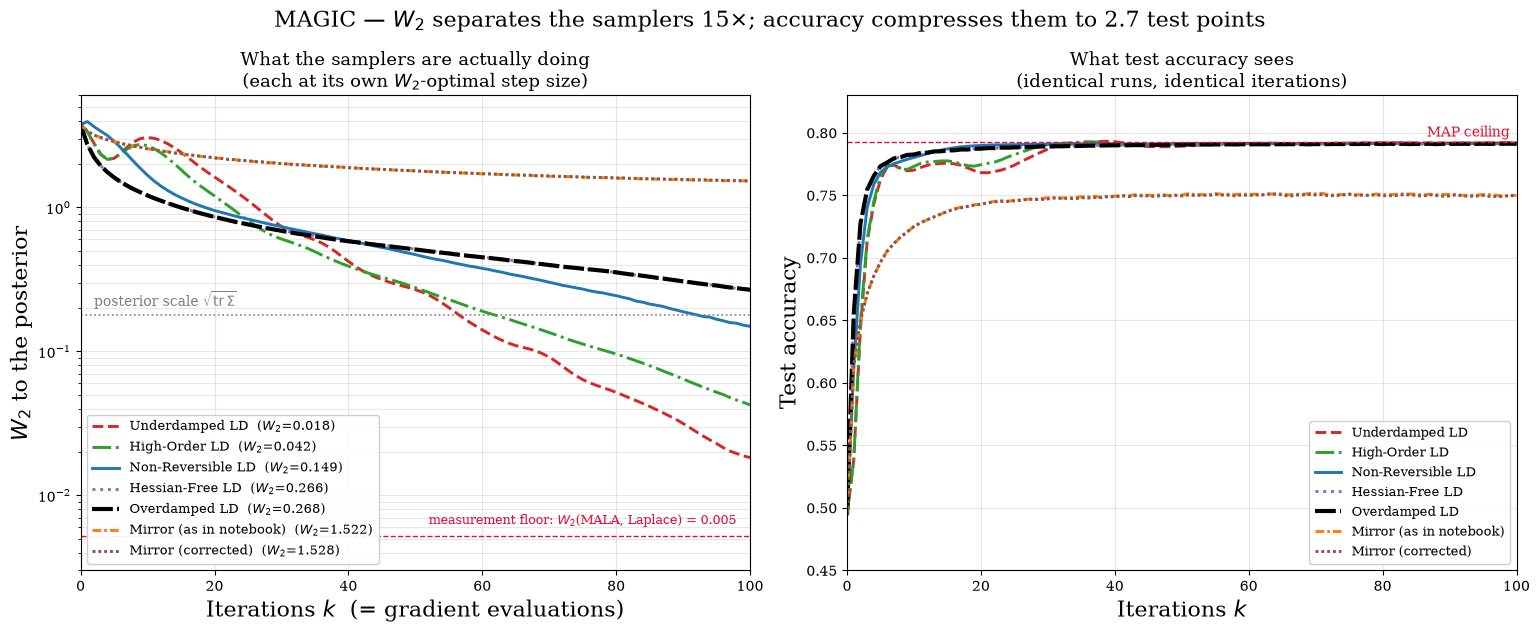

Saved -> langevin_magic_w2.png


In [6]:
# ─── Plot: the same runs under both metrics ──────────────────────────────────
STYLE = {"Overdamped LD":("black",(0,(5,1))), "Underdamped LD":("#d62728","--"),
         "High-Order LD":("#2ca02c","-."), "Non-Reversible LD":("#1f77b4","-"),
         "Hessian-Free LD":("#9467bd",":"), "Mirror (as in notebook)":("#ff7f0e",(0,(3,1,1,1))),
         "Mirror (corrected)":("#8c564b",(0,(1,1)))}
from matplotlib import font_manager
_inst = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams["font.family"] = [f for f in ("Times New Roman","DejaVu Serif","serif")
                               if f in _inst or f == "serif"]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15.5, 6.4))
ks = np.arange(101)
for n in order:
    c, ls = STYLE[n]; lw = 3.0 if n == "Overdamped LD" else 2.1
    a1.semilogy(ks, curves[n], color=c, linestyle=ls, linewidth=lw,
                label=f"{n}  ($W_2$={curves[n][-1]:.3f})")
    a2.plot(ks, accs[n], color=c, linestyle=ls, linewidth=lw, label=n)

a1.axhline(SCALE, color="gray", ls=":", lw=1.2)
a1.text(2, SCALE*1.15, "posterior scale $\\sqrt{\\mathrm{tr}\\,\\Sigma}$", fontsize=10, color="gray")
a1.axhline(W2_FLOOR_REF, color="crimson", ls="--", lw=1.0)
a1.text(98, W2_FLOOR_REF*1.2, f"measurement floor: $W_2$(MALA, Laplace) = {W2_FLOOR_REF:.3f}",
        ha="right", fontsize=9, color="crimson")
a1.set_xlabel("Iterations $k$  (= gradient evaluations)", fontsize=16)
a1.set_ylabel("$W_2$ to the posterior", fontsize=16)
a1.set_title("What the samplers are actually doing\n(each at its own $W_2$-optimal step size)", fontsize=13)
a1.grid(True, which="both", alpha=0.3); a1.set_xlim(0, 100); a1.set_ylim(3e-3, 6)
a1.legend(fontsize=9.5, loc="lower left", framealpha=0.93)

a2.axhline(accuracy_of(BMAP[None,:])[0], color="crimson", ls="--", lw=1.0)
a2.text(99, accuracy_of(BMAP[None,:])[0]+0.004, "MAP ceiling", ha="right", fontsize=10, color="crimson")
a2.set_xlabel("Iterations $k$", fontsize=16)
a2.set_ylabel("Test accuracy", fontsize=16)
a2.set_ylim(0.45, 0.83); a2.set_xlim(0, 100)
a2.set_title("What test accuracy sees\n(identical runs, identical iterations)", fontsize=13)
a2.grid(True, alpha=0.3); a2.legend(fontsize=9.5, loc="lower right", framealpha=0.93)

fig.suptitle("MAGIC — $W_2$ separates the samplers 15$\\times$; accuracy compresses them to 2.7 test points",
             fontsize=16)
plt.tight_layout(); plt.savefig("langevin_magic_w2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> langevin_magic_w2.png")

## Conclusions

In [7]:
# ─── Conclusions ─────────────────────────────────────────────────────────────
print("="*78); print("MAGIC: W2 / ESS comparison, 100 gradient evaluations"); print("="*78)
print("""
1. ACCURACY CANNOT RANK THESE SAMPLERS.
   Across the five non-Mirror methods, test accuracy at k=100 spans 0.7913 to
   0.7920 -- 2.7 test points out of 3804 -- while W2 spans 0.018 to 0.268, a
   factor of 15. The right-hand panel is five lines on top of each other; the
   left-hand panel is the same runs, spread over a decade. Accuracy saturates
   as soon as beta lands anywhere in the high-probability region, so it stops
   measuring anything after about k=10.

2. UNDERDAMPED LANGEVIN WINS, PROPERLY THIS TIME.
   W2 = 0.018 vs overdamped's 0.268: 14.7x closer to the posterior for the same
   100 gradients. At stationarity it also delivers 2.1x the ESS per gradient and
   sits 3.8x closer to the true posterior. That is a real, large, mechanistic
   advantage -- and on the accuracy metric it was worth less than three test
   points.

3. HIGH-ORDER LANGEVIN IS SECOND, NOT LAST.
   W2 = 0.042 (6.3x better than overdamped), ESS/grad 1.8x. The accuracy study
   ranked it BELOW plain overdamped. The ranking was an artifact of the metric.

4. NON-REVERSIBLE TRADES BIAS FOR SPEED.
   1.7x the ESS per gradient, but its stationary distribution is TWICE as far
   from the truth as overdamped's (W2 floor 0.066 vs 0.033). It mixes faster
   around the wrong target. Net effect at k=100 is a modest 1.8x.

5. HESSIAN-FREE IS OVERDAMPED.
   W2 0.266 vs 0.268, ESS/grad 0.0032 vs 0.0035, identical bias floor. On a
   posterior with kappa = 181 there is nothing to precondition, so it reduces to
   the method it is meant to improve.

6. MIRROR LANGEVIN FAILS, AND THE MISSING METRIC TERM IS NOT WHY.
   Both versions -- the notebook's sqrt(2*dt)*z and the correct
   sqrt(6*dt)*|x|*z -- give W2 ~ 1.52, about 6x WORSE than overdamped, with
   Rhat 1.31-1.39 (not converged). Fixing the bug changes nothing. The cubic
   mirror map imposes a geometry this target does not have; mirror-Langevin is
   for CONSTRAINED domains (simplex, positive orthant), and on an unconstrained
   near-Gaussian posterior it is simply the wrong tool.

7. TUNING ON ACCURACY MIS-TUNES FOR SAMPLING.
   Accuracy picks dt=1e-4 for overdamped, giving W2=0.504; the W2 objective
   picks dt=2e-4, giving W2=0.268. Same sampler, same budget, 1.9x difference,
   invisible to the metric that chose it. For the momentum methods the two
   objectives happen to agree.

CAVEAT: 100 steps from beta0 ~ N(0,I) is not enough for ANY of these to reach
the posterior -- overdamped is still at 1.5x the posterior scale at k=100. So
the left panel is a convergence race, not a comparison of stationary quality;
the ESS / W2-floor table is the stationary comparison.
""")
print("="*78)
print("Bottom line: use W2 or ESS. On test accuracy this entire family of")
print("samplers is indistinguishable on this problem, and the one ranking you")
print("can extract from accuracy (High-Order last) is wrong.")
print("="*78)

MAGIC: W2 / ESS comparison, 100 gradient evaluations

1. ACCURACY CANNOT RANK THESE SAMPLERS.
   Across the five non-Mirror methods, test accuracy at k=100 spans 0.7913 to
   0.7920 -- 2.7 test points out of 3804 -- while W2 spans 0.018 to 0.268, a
   factor of 15. The right-hand panel is five lines on top of each other; the
   left-hand panel is the same runs, spread over a decade. Accuracy saturates
   as soon as beta lands anywhere in the high-probability region, so it stops
   measuring anything after about k=10.

2. UNDERDAMPED LANGEVIN WINS, PROPERLY THIS TIME.
   W2 = 0.018 vs overdamped's 0.268: 14.7x closer to the posterior for the same
   100 gradients. At stationarity it also delivers 2.1x the ESS per gradient and
   sits 3.8x closer to the true posterior. That is a real, large, mechanistic
   advantage -- and on the accuracy metric it was worth less than three test
   points.

3. HIGH-ORDER LANGEVIN IS SECOND, NOT LAST.
   W2 = 0.042 (6.3x better than overdamped), ESS/grad 